In [30]:
import torch
import numpy as np
import pandas as pd
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.optim import AdamW
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn import metrics

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [31]:
# df_electron = pd.read_csv("../../Data_Separated/Bias/electronBias.csv")
# df_muon = pd.read_csv("../../Data_Separated/Bias/muonBias.csv")
df_electron = pd.read_csv("../../Data_Separated/Bias/Filter_By_MLP/electron.csv")
df_muon = pd.read_csv("../../Data_Separated/Bias/Filter_By_MLP/muon.csv")
print(df_electron.shape)
print(df_muon.shape)
print(df_muon.columns)

(80103, 11)
(486652, 11)
Index(['track_TRTHits', 'track_PixelHits', 'track_SCTHits', 'track_PixeldEdX',
       'topo_cluster_eta', 'topo_cluster_phi', 'topo_cluster_EM_prob',
       'topo_cluster_pt', 'pt_ratio', 'topo_cluster_lambda',
       'topo_cluster_lambda2'],
      dtype='object')


In [32]:
#filtering
df_electron_clean = df_electron[
    (df_electron['topo_cluster_eta'] != -10.0) &
    (df_electron['topo_cluster_pt'] != -1.0) &
    (df_electron['topo_cluster_phi'] != -10.0) &
    (df_electron['topo_cluster_EM_prob'] != -1.0) &
    (df_electron['pt_ratio'] != -1.0) &
    (df_electron['topo_cluster_lambda'] != -1.0) &
    (df_electron['topo_cluster_lambda2'] != -1.0)
]

df_muon_clean = df_muon[
    (df_muon['topo_cluster_eta'] != -10.0) &
    (df_muon['topo_cluster_pt'] != -1.0) &
    (df_muon['topo_cluster_phi'] != -10.0) &
    (df_muon['topo_cluster_EM_prob'] != -1.0) &
    (df_muon['pt_ratio'] != -1.0) &
    (df_muon['topo_cluster_lambda'] != -1.0) &
    (df_muon['topo_cluster_lambda2'] != -1.0)
]

df_electron_clean['label'] = 1  # Electrons = 1
df_muon_clean['label'] = 0

df_full = pd.concat([df_electron_clean, df_muon_clean], ignore_index=True)

In [33]:
num_muons = df_muon_clean.shape[0]
num_elec = df_electron_clean.shape[0]
pos_weight = torch.tensor(num_muons/num_elec).to(DEVICE)
print(num_muons)
print(num_elec)

486652
80103


In [34]:
feature_columns = [col for col in df_full.columns if col not in ['event', 'track_idx', 'label']]
x_data = df_full[feature_columns]  # 11 features
y_data = df_full['label']  

test_size = 0.2
x_train, x_val, y_train, y_val = train_test_split(x_data.values, y_data.values, test_size=test_size, shuffle=True)


scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)


x_train = torch.tensor(x_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
x_val = torch.tensor(x_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)

train_dataset = TensorDataset(x_train, y_train)
val_dataset = TensorDataset(x_val, y_val)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=True, num_workers=4, pin_memory=True)



In [35]:
print(np.shape(x_train))
print(np.shape(x_val))
print(np.shape(y_train))
print(np.shape(y_val))
in_data = np.shape(x_train)[1]

torch.Size([453404, 11])
torch.Size([113351, 11])
torch.Size([453404])
torch.Size([113351])


In [36]:
class Linear(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Sequential(
            nn.Linear(in_data, 20),
            nn.ReLU(),
            nn.Linear(20, 40),
            nn.ReLU(),
            nn.Linear(40, 60),
            nn.ReLU(),
            nn.Linear(60, 40),
            nn.ReLU(),
            nn.Linear(40, 20),
            nn.ReLU(),
            nn.Linear(20, 1)
        )

    def forward(self, sample):
        return self.linear(sample)
    
    def param(self):
        count = 0
        for parameter in self.parameters():
            count += parameter.numel()
        return count

In [37]:
num_elec_val = (y_val == 1).sum().item()
num_muons_val = (y_val == 0).sum().item()

In [38]:
def train(model, epochs):
    optimizer = AdamW(model.parameters())
    loss = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    
    loss_history = []
    accuracy_el = []
    accuracy_mu = []
    for epoch in range(epochs):
        score_el = 0.0
        score_mu = 0.0
        acc_el = 0.0
        acc_mu = 0.0
        los = 0.0
    
        print(f"Epoch {epoch+1}/{epochs}")
        model.train()
        for batch in train_loader:
            sample, true = batch
            sample = sample.to(DEVICE)
            true = true.to(DEVICE)
            pred = model(sample)[:,0]
            l = loss(pred, true)
            l.backward()
            optimizer.step()
            optimizer.zero_grad()
            
        model.eval()
        for batch in val_loader:
            sample, true = batch
            sample = sample.to(DEVICE)
            true = true.to(DEVICE)
            pred = model(sample)[:,0]
            l = loss(pred, true)
            los += l.item()
            
            pred = torch.sigmoid(pred)
            pred = (pred >= 0.5).float()
            
            score_el += ((true == 1) & (pred == 1)).sum().item()
            score_mu += ((true == 0) & (pred == 0)).sum().item()
                
            
        loss_history.append(los/len(val_loader))
        acc_el = score_el/num_elec_val
        acc_mu = score_mu/num_muons_val
        accuracy_el.append(acc_el)
        accuracy_mu.append(acc_mu)
        print(f"Electron Accuracy: {acc_el*100}")
        print(f"Muon Accuracy: {acc_mu*100}\n")
        
    return model, loss_history, accuracy_el, accuracy_mu

In [ ]:
model = Linear().to(DEVICE)
print(model.param())
model, loss, ac_el, ac_mu =train(model, 30)

6821
Epoch 1/30


Electron Accuracy: 100.0
Muon Accuracy: 99.99279123414071

Epoch 2/30
Electron Accuracy: 99.9938450175417
Muon Accuracy: 99.99588070522326

Epoch 3/30
Electron Accuracy: 99.9938450175417
Muon Accuracy: 99.99485088152909

Epoch 4/30
Electron Accuracy: 99.9938450175417
Muon Accuracy: 99.99588070522326

Epoch 5/30
Electron Accuracy: 100.0
Muon Accuracy: 99.99176141044653

Epoch 6/30
Electron Accuracy: 100.0
Muon Accuracy: 98.93001318174328

Epoch 7/30


0.9891304347826086 0.9794112916197523


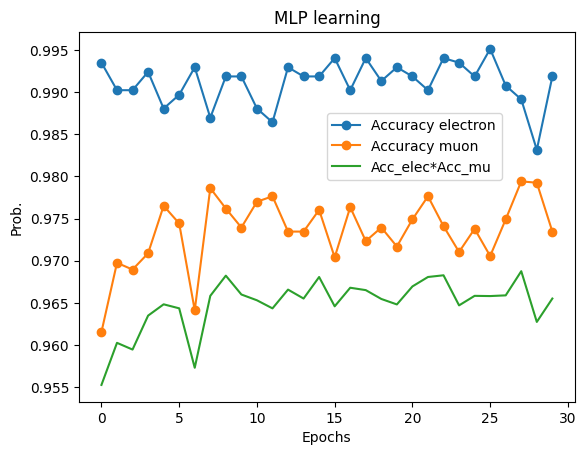

In [ ]:
plt.plot(ac_el, '-o', label="Accuracy electron")
plt.plot(ac_mu, '-o', label="Accuracy muon")
iloczyn = np.array(ac_mu)*np.array(ac_el)
plt.plot(iloczyn, label="Acc_elec*Acc_mu")
argm = np.argmax(iloczyn)
print(ac_el[argm], ac_mu[argm])
plt.legend(loc=[0.5,0.6])
plt.title("MLP learning")
plt.xlabel("Epochs")
plt.ylabel("Prob.")
plt.savefig("Plot_nauka.png")

Najlepszy próg: 0.714


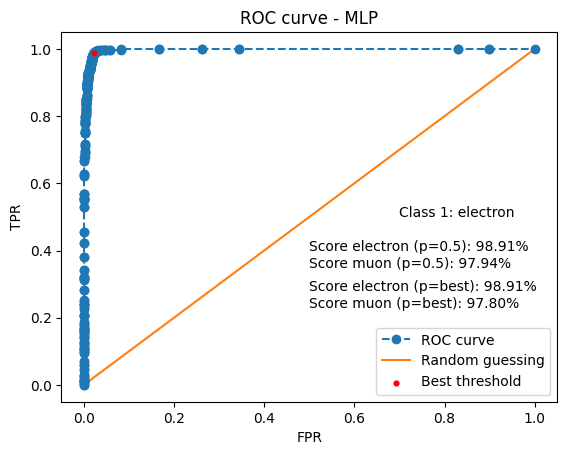

In [ ]:
#ROC CURVE AND BEST THRESHOLD
model.eval()
model = model.to(DEVICE)
x_val = x_val.to(DEVICE)
pred = model(x_val)
prob_norm = torch.sigmoid(pred).detach().cpu().numpy()

fpr, tpr, thresholds = metrics.roc_curve(y_val, prob_norm)  # dla 1 czyli mionelektrony
plt.plot(fpr, tpr, 'o--', zorder = 1, label='ROC curve')
plt.plot([0,1],[0,1], zorder=0, label = 'Random guessing')
plt.title("ROC curve - MLP")
plt.text(0.7,0.5, 'Class 1: electron')
plt.text(0.5,0.4, f'Score electron (p=0.5): {ac_el[argm]*100:.2f}% ')
plt.text(0.5,0.35, f'Score muon (p=0.5): {ac_mu[argm]*100:.2f}% ')

J = tpr - fpr
ix = np.argmax(J)
best_thresh = thresholds[ix]
print(f"Najlepszy próg: {best_thresh:.3f}")

score_el = 0.0
score_mu = 0.0

for batch in val_loader:
    sample, true = batch
    sample = sample.to(DEVICE)
    true = true.to(DEVICE)
    pred = model(sample)[:,0]
    
    pred = torch.sigmoid(pred)
    pred = (pred >= best_thresh).float()
    
    score_el += ((true == 1) & (pred == 1)).sum().item()
    score_mu += ((true == 0) & (pred == 0)).sum().item()
        
    
acc_el = score_el/(num_elec_val)
acc_mu = score_mu/(num_muons_val)


plt.text(0.5,0.28, f'Score electron (p=best): {acc_el*100:.2f}% ')
plt.text(0.5,0.23, f'Score muon (p=best): {acc_mu*100:.2f}% ')
plt.scatter(fpr[ix], tpr[ix], c='red', s=12, zorder =2, label = 'Best threshold')
plt.legend()
plt.xlabel("FPR")
plt.ylabel("TPR")
# plt.savefig(r"C:\Users\qmiko\Desktop\cern\Plots_ml\Mlp_roc.png")
plt.show()

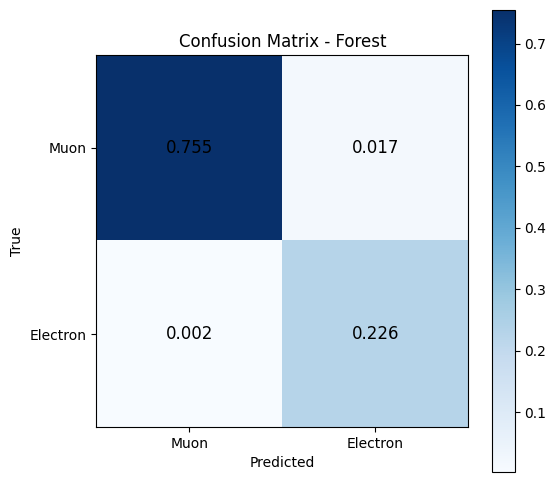

In [ ]:
true = y_val

model.eval()
model = model.to(DEVICE)
x_val = x_val.to(DEVICE)
pred = model(x_val)
prob_norm = torch.sigmoid(pred).detach().cpu().numpy()

pred_th = (prob_norm >= best_thresh).astype(int) #1 to elektorn i to jest jako Positive
mat = metrics.confusion_matrix(true, pred_th)
mat = mat/np.sum(mat)

fig, ax = plt.subplots(figsize=(6,6))
im = ax.imshow(mat, cmap='Blues')

# dodanie kolorowego paska obok
cbar = ax.figure.colorbar(im, ax=ax)


# podpisy osi
classes = ["Muon", "Electron"]
ax.set_xticks(np.arange(len(classes)))
ax.set_yticks(np.arange(len(classes)))
ax.set_xticklabels(classes)
ax.set_yticklabels(classes)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix - Forest")


# dopisywanie wartości w komórkach
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        ax.text(j, i, f"{mat[i, j]:.3f}", ha="center", va="center", color="black", fontsize=12)

# plt.savefig(r"C:\Users\qmiko\Desktop\cern\Plots_ml\Mlp_matrix.png")
plt.show()

In [ ]:
example_input, _ = next(iter(val_loader))
example_input = example_input[:1].to(DEVICE)
scripted = torch.jit.trace(model, example_input)
scripted.save("trained/model.pt")